# Dataset Analysis — Temporal, Spatial, Water Fraction, Seasonal
**WorldView-3 | 64 scenes | 17,445 chips | Train/Val vs Test split**

All analyses are at **scene level** (64 scenes = 64 data points).
Each scene is one satellite acquisition — chip counts vary by scene size and are not used here.

1. Temporal distribution (year and month of acquisition)
2. Seasonal distribution (spring/summer/autumn/winter)
3. Spatial distribution (geographic centroid of each scene)
4. Water fraction distribution (mean water fraction per scene)

In [1]:
# ── Cell 1: Setup ──
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import rasterio
from rasterio.warp import transform as rio_transform
from pathlib import Path
from tqdm import tqdm

BASE_DIR  = Path('/mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask')
CHIPS_DIR = BASE_DIR / 'images/chips_images/images'
MASKS_DIR = BASE_DIR / 'images/chips_masks/masks'
OUT_DIR   = BASE_DIR / 'results/dataset_analysis'
OUT_DIR.mkdir(parents=True, exist_ok=True)

with open(BASE_DIR / 'results/unet_training/test_chips.json') as f:
    test_chip_names = set(json.load(f))

all_chips = sorted(CHIPS_DIR.glob('*.tif'))

MONTH_MAP = {
    'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,
    'jul':7,'aug':8,'sep':9,'oct':10,'nov':11,'dec':12
}
MONTH_LABELS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
SEASON_MAP   = {1:'Winter',2:'Winter',3:'Spring',4:'Spring',5:'Spring',
                6:'Summer',7:'Summer',8:'Summer',9:'Autumn',10:'Autumn',
                11:'Autumn',12:'Winter'}
COLORS = {'train/val': '#2E75B6', 'test': '#E8A838'}

def parse_date(name):
    m = re.search(r'(\d{4})_(\d{2})_(\d{2})', name)
    if m:
        return int(m.group(1)), int(m.group(2))
    m = re.match(r'(\d{2})([A-Za-z]{3})(\d{2})', name)
    if m:
        year = 2000 + int(m.group(1))
        mon  = m.group(2).lower()
        return year, MONTH_MAP.get(mon, 0)
    return None, None

def get_scene_id(filename):
    name = Path(filename).stem
    if '_clipped_' in name: return name.split('_clipped_')[0]
    if '_clip_' in name:    return name.split('_clip_')[0]
    return name

def get_centroid_latlon(chip_path):
    try:
        with rasterio.open(chip_path) as src:
            bounds = src.bounds
            crs    = src.crs
        cx  = (bounds.left + bounds.right) / 2
        cy  = (bounds.bottom + bounds.top) / 2
        lon, lat = rio_transform(crs, 'EPSG:4326', [cx], [cy])
        return float(lat[0]), float(lon[0])
    except Exception:
        return None, None

print(f'Total chips found: {len(all_chips):,}')
print(f'Test chips:        {len(test_chip_names):,}')

Total chips found: 17,445
Test chips:        4,788


In [2]:
# ── Cell 2: Build Scene Metadata ──
# For each scene: acquisition date, centroid lat/lon, mean water fraction, split.
# Uses one representative chip per scene for date and location.
# Cached to CSV after first run — delete dataset_analysis/scene_metadata.csv to rerun.

CACHE = OUT_DIR / 'scene_metadata.csv'

if CACHE.exists():
    scene_df = pd.read_csv(CACHE)
    print(f'Loaded from cache: {len(scene_df)} scenes')
else:
    # Group chips by scene
    scene_chips = {}
    for chip in all_chips:
        sid = get_scene_id(chip.name)
        if sid not in scene_chips:
            scene_chips[sid] = []
        scene_chips[sid].append(chip)

    rows = []
    for scene_id, chips in tqdm(scene_chips.items(), desc='Reading scene metadata'):
        # Split: test if any chip is in test set
        split = 'test' if any(c.name in test_chip_names for c in chips) else 'train/val'

        # Date from scene name
        year, month = parse_date(scene_id)

        # Centroid from first chip
        lat, lon = get_centroid_latlon(chips[0])

        # Mean water fraction across all chips in scene
        fracs = []
        for chip in chips:
            mask_path = MASKS_DIR / chip.name
            if mask_path.exists():
                with rasterio.open(mask_path) as src:
                    fracs.append(float((src.read(1) > 0).mean()))
        water_frac = float(np.mean(fracs)) if fracs else None

        rows.append({
            'scene':      scene_id,
            'split':      split,
            'n_chips':    len(chips),
            'year':       year,
            'month':      month,
            'season':     SEASON_MAP.get(month, 'Unknown') if month else 'Unknown',
            'lat':        lat,
            'lon':        lon,
            'water_frac': water_frac,
        })

    scene_df = pd.DataFrame(rows)
    scene_df.to_csv(CACHE, index=False)
    print(f'Saved to cache: {len(scene_df)} scenes')

print(f'\nTotal scenes: {len(scene_df)}')
print(f'  Train/val:  {(scene_df["split"]=="train/val").sum()}')
print(f'  Test:       {(scene_df["split"]=="test").sum()}')
print(f'\nYear range: {int(scene_df["year"].min())} – {int(scene_df["year"].max())}')
print(f'\nScenes per split:')
print(scene_df.groupby(['split','season']).size().unstack(fill_value=0).to_string())

Reading scene metadata: 100%|██████████| 64/64 [34:54<00:00, 32.72s/it]

Saved to cache: 64 scenes

Total scenes: 64
  Train/val:  51
  Test:       13

Year range: 2011 – 2026

Scenes per split:
season     Autumn  Spring  Summer  Winter
split                                    
test            4       0       7       2
train/val      20      11      19       1


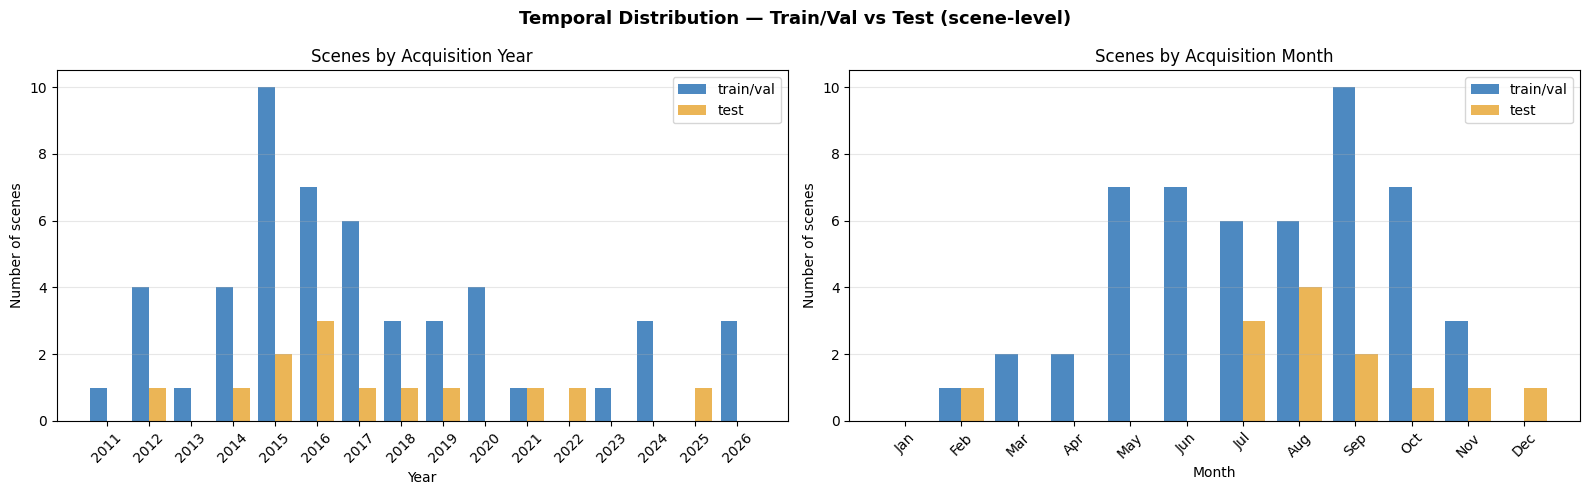

Scenes per year per split:
split  test  train/val
year                  
2011      0          1
2012      1          4
2013      0          1
2014      1          4
2015      2         10
2016      3          7
2017      1          6
2018      1          3
2019      1          3
2020      0          4
2021      1          1
2022      1          0
2023      0          1
2024      0          3
2025      1          0
2026      0          3


In [3]:
# ── Cell 3: Figure 1 — Temporal Distribution (Year + Month) ──
# Scene-level: each bar = number of scenes acquired in that year/month.

scene_valid = scene_df[scene_df['year'].notna()].copy()
w = 0.4

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Year
years = sorted(scene_valid['year'].unique())
for split in ['train/val', 'test']:
    counts = scene_valid[scene_valid['split']==split].groupby('year').size()
    offset = -w/2 if split == 'train/val' else w/2
    axes[0].bar([j + offset for j in range(len(years))],
                [counts.get(y, 0) for y in years],
                width=w, label=split, color=COLORS[split], alpha=0.85)
axes[0].set_xticks(range(len(years)))
axes[0].set_xticklabels([str(int(y)) for y in years], rotation=45)
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Number of scenes')
axes[0].set_title('Scenes by Acquisition Year')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

# Month
for split in ['train/val', 'test']:
    counts = scene_valid[scene_valid['split']==split].groupby('month').size()
    offset = -w/2 if split == 'train/val' else w/2
    axes[1].bar([j + offset for j in range(12)],
                [counts.get(m, 0) for m in range(1, 13)],
                width=w, label=split, color=COLORS[split], alpha=0.85)
axes[1].set_xticks(range(12))
axes[1].set_xticklabels(MONTH_LABELS, rotation=45)
axes[1].set_xlabel('Month'); axes[1].set_ylabel('Number of scenes')
axes[1].set_title('Scenes by Acquisition Month')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Temporal Distribution — Train/Val vs Test (scene-level)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig1_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

print('Scenes per year per split:')
print(scene_valid.groupby(['year','split']).size().unstack(fill_value=0).to_string())

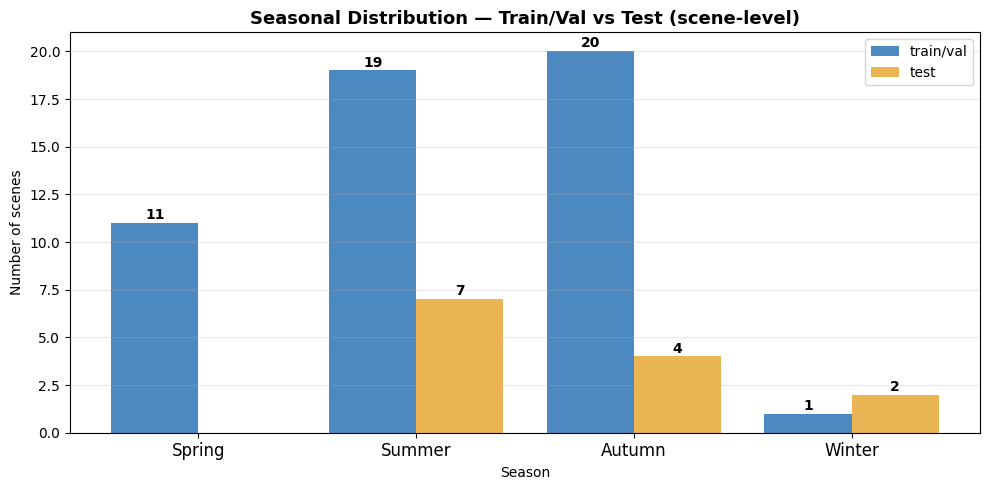

Scenes per season per split:
split   test  train/val
season                 
Autumn     4         20
Spring     0         11
Summer     7         19
Winter     2          1


In [4]:
# ── Cell 4: Figure 2 — Seasonal Distribution ──
# Scene-level: each bar = number of scenes in that season.

scene_seas = scene_df[scene_df['season'].notna() & (scene_df['season'] != 'Unknown')].copy()
seasons = ['Spring', 'Summer', 'Autumn', 'Winter']
w = 0.4

fig, ax = plt.subplots(figsize=(10, 5))

for split in ['train/val', 'test']:
    counts = scene_seas[scene_seas['split']==split].groupby('season').size()
    offset = -w/2 if split == 'train/val' else w/2
    bars = ax.bar([j + offset for j in range(len(seasons))],
                  [counts.get(s, 0) for s in seasons],
                  width=w, label=split, color=COLORS[split], alpha=0.85)
    for bar, val in zip(bars, [counts.get(s, 0) for s in seasons]):
        if val > 0:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                    str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(range(len(seasons)))
ax.set_xticklabels(seasons, fontsize=12)
ax.set_xlabel('Season'); ax.set_ylabel('Number of scenes')
ax.set_title('Seasonal Distribution — Train/Val vs Test (scene-level)', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig2_seasonal.png', dpi=150, bbox_inches='tight')
plt.show()

print('Scenes per season per split:')
print(scene_seas.groupby(['season','split']).size().unstack(fill_value=0).to_string())

In [ ]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'contextily', 'geopandas', '--break-system-packages'], check=True)

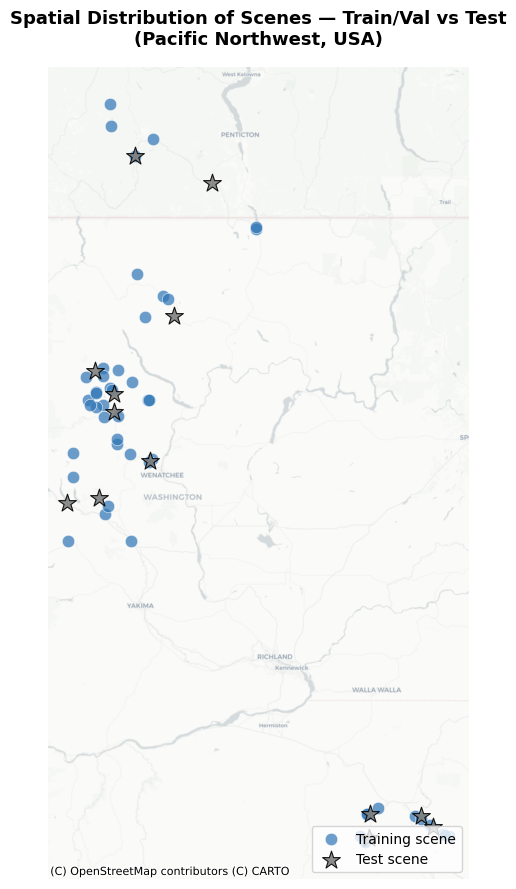

In [11]:
# ── Cell 5: Figure 3 — Spatial Distribution with basemap ──

import contextily as ctx
import geopandas as gpd
from shapely.geometry import Point

scene_geo = scene_df[scene_df['lat'].notna() & scene_df['lon'].notna()].copy()

# Convert to GeoDataFrame in Web Mercator (required by contextily)
geometry = [Point(lon, lat) for lon, lat in zip(scene_geo['lon'], scene_geo['lat'])]
gdf = gpd.GeoDataFrame(scene_geo, geometry=geometry, crs='EPSG:4326').to_crs('EPSG:3857')

fig, ax = plt.subplots(figsize=(14, 9))

# Train scenes
train_gdf = gdf[gdf['split'] == 'train/val']
train_gdf.plot(ax=ax, color='#2E75B6', markersize=80, alpha=0.7,
               marker='o', edgecolors='white', linewidths=0.5, label='Training scene', zorder=3)

# Test scenes
test_gdf = gdf[gdf['split'] == 'test']
test_gdf.plot(ax=ax, color='grey', markersize=180, alpha=0.9,
              marker='*', edgecolors='black', linewidths=0.8, label='Test scene', zorder=4)

# Basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=8)

ax.set_axis_off()
ax.legend(fontsize=10, loc='lower right')
ax.set_title('Spatial Distribution of Scenes — Train/Val vs Test\n(Pacific Northwest, USA)',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig3_spatial.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_2388414/930104463.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot([train_wf, test_wf], labels=['Train/val', 'Test'],


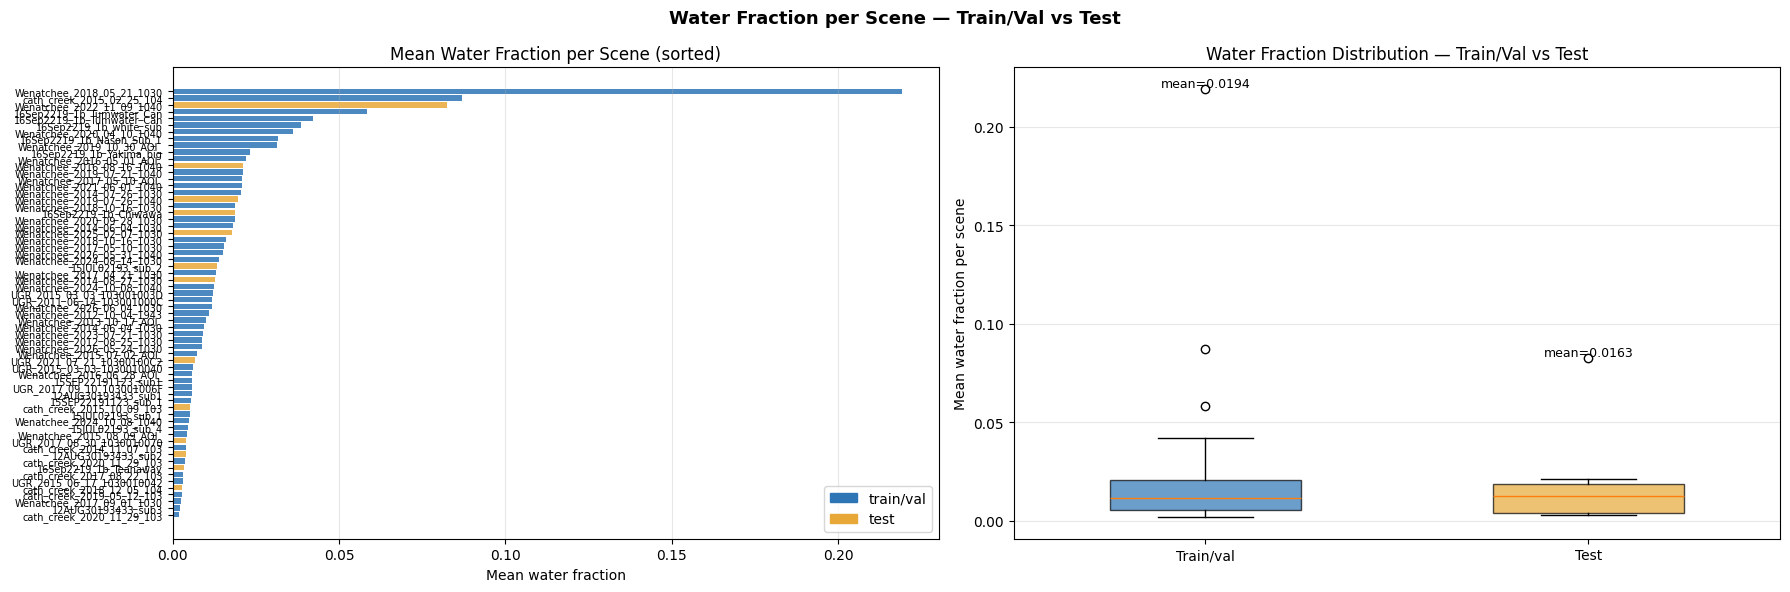

train/val: mean=0.0194, median=0.0117, min=0.0018, max=0.2193
test: mean=0.0163, median=0.0128, min=0.0027, max=0.0825


In [5]:
# ── Cell 6: Figure 4 — Water Fraction per Scene ──
# Scene-level: mean water fraction across all chips in each scene.

scene_wf = scene_df[scene_df['water_frac'].notna()].copy().sort_values('water_frac')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar chart — one bar per scene
colors_bar = [COLORS[s] for s in scene_wf['split']]
axes[0].barh(range(len(scene_wf)), scene_wf['water_frac'],
             color=colors_bar, alpha=0.85)
axes[0].set_yticks(range(len(scene_wf)))
axes[0].set_yticklabels([s[:25] for s in scene_wf['scene']], fontsize=7)
axes[0].set_xlabel('Mean water fraction')
axes[0].set_title('Mean Water Fraction per Scene (sorted)')
legend_patches = [mpatches.Patch(color='#2E75B6', label='train/val'),
                  mpatches.Patch(color='#E8A838', label='test')]
axes[0].legend(handles=legend_patches); axes[0].grid(axis='x', alpha=0.3)

# Box plot comparison
train_wf = scene_wf[scene_wf['split']=='train/val']['water_frac']
test_wf  = scene_wf[scene_wf['split']=='test']['water_frac']
bp = axes[1].boxplot([train_wf, test_wf], labels=['Train/val', 'Test'],
                     patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('#2E75B6'); bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('#E8A838'); bp['boxes'][1].set_alpha(0.7)
axes[1].set_ylabel('Mean water fraction per scene')
axes[1].set_title('Water Fraction Distribution — Train/Val vs Test')
axes[1].grid(axis='y', alpha=0.3)

# Add mean annotation
for i, (data, label) in enumerate([(train_wf,'train/val'),(test_wf,'test')], 1):
    axes[1].text(i, data.max()+0.001, f'mean={data.mean():.4f}',
                 ha='center', fontsize=9)

plt.suptitle('Water Fraction per Scene — Train/Val vs Test', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig4_water_fraction.png', dpi=150, bbox_inches='tight')
plt.show()

for split, data in [('train/val', train_wf), ('test', test_wf)]:
    print(f'{split}: mean={data.mean():.4f}, median={data.median():.4f}, min={data.min():.4f}, max={data.max():.4f}')

In [6]:
# ── Cell 7: Summary Statistics ──

print('=' * 60)
print('DATASET SUMMARY — SCENE LEVEL')
print('=' * 60)

for split in ['train/val', 'test']:
    sub = scene_df[scene_df['split']==split]
    sub_valid = sub[sub['year'].notna()]
    sub_wf = sub[sub['water_frac'].notna()]
    print(f'\n{split.upper()}:')
    print(f'  Scenes:             {len(sub)}')
    print(f'  Total chips:        {sub["n_chips"].sum():,}')
    if sub_valid['year'].notna().any():
        print(f'  Year range:         {int(sub_valid["year"].min())} – {int(sub_valid["year"].max())}')
    print(f'  Seasons:            {sub_valid["season"].value_counts().to_dict()}')
    print(f'  Mean water frac:    {sub_wf["water_frac"].mean():.4f}')
    print(f'  Median water frac:  {sub_wf["water_frac"].median():.4f}')
    print(f'  Min water frac:     {sub_wf["water_frac"].min():.4f}')
    print(f'  Max water frac:     {sub_wf["water_frac"].max():.4f}')

print(f'\nAll figures saved to: {OUT_DIR}')

DATASET SUMMARY — SCENE LEVEL

TRAIN/VAL:
  Scenes:             51
  Total chips:        12,657
  Year range:         2011 – 2026
  Seasons:            {'Autumn': 20, 'Summer': 19, 'Spring': 11, 'Winter': 1}
  Mean water frac:    0.0194
  Median water frac:  0.0117
  Min water frac:     0.0018
  Max water frac:     0.2193

TEST:
  Scenes:             13
  Total chips:        4,788
  Year range:         2012 – 2025
  Seasons:            {'Summer': 7, 'Autumn': 4, 'Winter': 2}
  Mean water frac:    0.0163
  Median water frac:  0.0128
  Min water frac:     0.0027
  Max water frac:     0.0825

All figures saved to: /mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask/results/dataset_analysis
